# PGL learned-mask analysis

Compare hard-mask selected and unselected training edges by graph degree and by within-user visual/text affinity. The analysis is associative, not causal.

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import mannwhitneyu, wilcoxon

if int(torch.__version__.split('.')[0]) < 2:
    raise RuntimeError(
        'Select the explainable kernel (PyTorch >= 2). '
        'The mmrec/PyTorch 1.11 kernel cannot load this checkpoint.'
    )

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')

RUN_NAME = 'PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39'

def find_src_dir():
    cwd = Path.cwd()
    candidates = [cwd, cwd / 'src', *cwd.parents]
    for candidate in candidates:
        if (candidate / 'saved').is_dir() and (candidate / 'mask_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate PGL/src from the current directory.')

SRC_DIR = find_src_dir()
ANALYSIS_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}-analysis.pt'
CHECKPOINT_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}.pth'

assert ANALYSIS_PATH.is_file(), ANALYSIS_PATH
assert CHECKPOINT_PATH.is_file(), CHECKPOINT_PATH
print('PyTorch:', torch.__version__)
print('Analysis:', ANALYSIS_PATH)
print('Checkpoint:', CHECKPOINT_PATH)

PyTorch: 2.2.1+cu118
Analysis: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39-analysis.pt
Checkpoint: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39.pth


## 1. Edge-level table and mask checks

In [2]:
analysis = torch.load(ANALYSIS_PATH, map_location='cpu', weights_only=False)
metadata = analysis['metadata']
mask_data = analysis['masks']['masked_branch']

user_ids = analysis['ui_edges']['user_ids'].long()
item_ids = analysis['ui_edges']['item_ids'].long()
mask_logits = mask_data['logits'].float()
mask_probability = mask_data['probabilities'].float()
selected = mask_data['selected_at_keep_ratio'].bool()

n_edges = metadata['num_interactions']
n_users = metadata['num_users']
n_items = metadata['num_items']
expected_selected = int(n_edges * metadata['mask_keep_ratio'])

assert len(user_ids) == len(item_ids) == len(mask_logits) == len(selected) == n_edges
assert int(user_ids.min()) >= 0 and int(user_ids.max()) < n_users
assert int(item_ids.min()) >= 0 and int(item_ids.max()) < n_items
assert torch.allclose(mask_probability, torch.sigmoid(mask_logits), atol=1e-7)
assert int(selected.sum()) == expected_selected

edge_df = pd.DataFrame({
    'edge_id': np.arange(n_edges, dtype=np.int64),
    'user_id': user_ids.numpy(),
    'item_id': item_ids.numpy(),
    'mask_logit': mask_logits.numpy(),
    'mask_probability': mask_probability.numpy(),
    'selected': selected.numpy(),
})
del analysis, mask_data, user_ids, item_ids, mask_logits, mask_probability, selected
gc.collect()

print(f'Edges: {len(edge_df):,}')
print(f'Selected: {edge_df.selected.sum():,} ({edge_df.selected.mean():.2%})')
print(f'Unselected: {(~edge_df.selected).sum():,}')
edge_df.head()

Edges: 118,551
Selected: 35,565 (30.00%)
Unselected: 82,986


,edge_id,user_id,item_id,mask_logit,mask_probability,selected
0,0,0,0,-0.859371,0.297471,True
1,1,0,1587,-0.977345,0.273419,False
2,2,0,1879,-0.875220,0.294169,True
3,3,1,0,-0.821523,0.305441,True
4,4,1,1434,-0.836464,0.302280,True


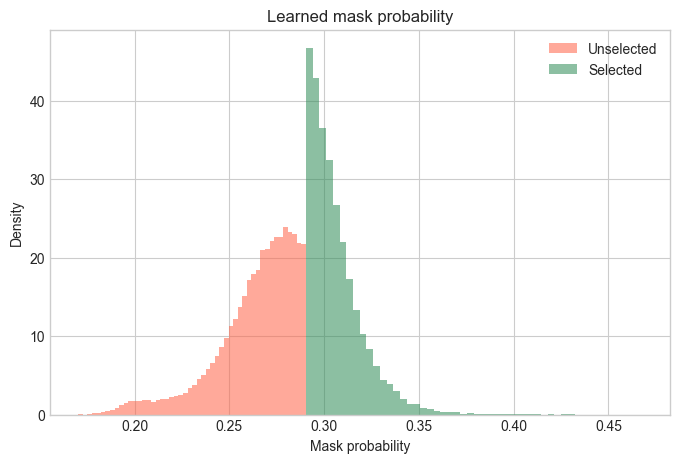

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for flag, label, color in [
    (False, 'Unselected', 'tomato'),
    (True, 'Selected', 'seagreen'),
]:
    values = edge_df.loc[edge_df.selected.eq(flag), 'mask_probability']
    ax.hist(values, bins=50, density=True, alpha=0.55, label=label, color=color)
ax.set(xlabel='Mask probability', ylabel='Density', title='Learned mask probability')
ax.legend()
plt.show()

## 2. Edge degree and normalized propagation weight

In [5]:
user_degree = np.bincount(edge_df.user_id, minlength=n_users)
item_degree = np.bincount(edge_df.item_id, minlength=n_items)
edge_df['user_degree'] = user_degree[edge_df.user_id.to_numpy()]
edge_df['item_degree'] = item_degree[edge_df.item_id.to_numpy()]
edge_df['edge_degree'] = np.sqrt(edge_df.user_degree * edge_df.item_degree)
edge_df['normalized_weight'] = 1.0 / edge_df.edge_degree

assert np.isfinite(edge_df[['edge_degree', 'normalized_weight']]).all().all()
assert (edge_df.edge_degree > 0).all()

degree_summary = (
    edge_df.groupby('selected')['edge_degree']
    .agg(
        count='count',
        mean='mean',
        median='median',
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        q90=lambda values: values.quantile(0.90),
    )
    .rename(index={False: 'unselected', True: 'selected'})
)
degree_summary

,count,mean,median,q25,q75,q90
selected,,,,,,
unselected,82986,21.209945,16.733201,10.488088,27.147744,40.792156
selected,35565,15.337765,11.832160,6.928203,20.445048,30.594117


Mann-Whitney U: 1,064,536,166
p-value: 0.000e+00
Rank-biserial effect size: -0.278622


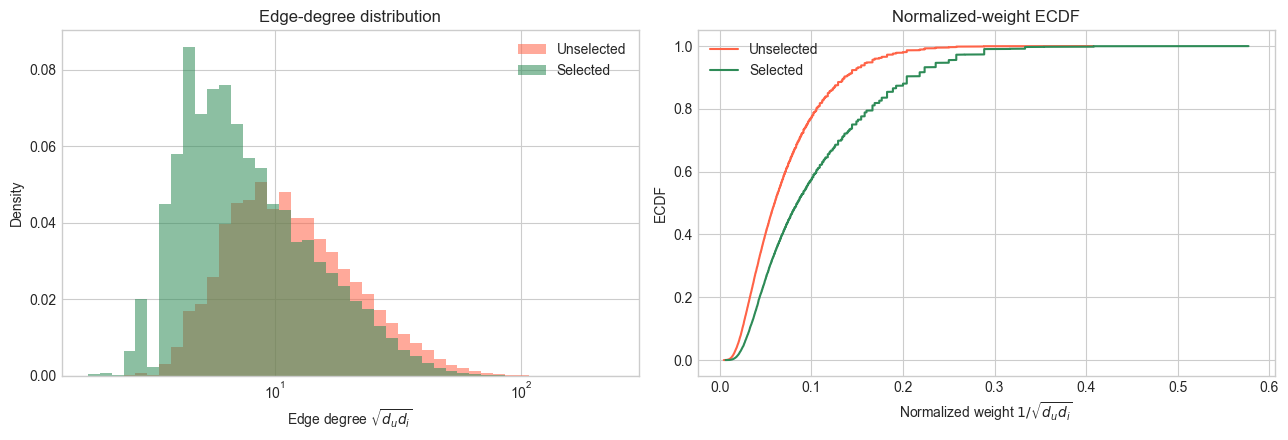

In [6]:
selected_degree = edge_df.loc[edge_df.selected, 'edge_degree'].to_numpy()
unselected_degree = edge_df.loc[~edge_df.selected, 'edge_degree'].to_numpy()

u_statistic, degree_p_value = mannwhitneyu(
    selected_degree, unselected_degree, alternative='two-sided'
)
rank_biserial = 2.0 * u_statistic / (len(selected_degree) * len(unselected_degree)) - 1.0
print(f'Mann-Whitney U: {u_statistic:,.0f}')
print(f'p-value: {degree_p_value:.3e}')
print(f'Rank-biserial effect size: {rank_biserial:.6f}')

def ecdf(values):
    ordered = np.sort(np.asarray(values))
    cumulative = np.arange(1, len(ordered) + 1) / len(ordered)
    return ordered, cumulative

positive_min = edge_df.edge_degree.min()
degree_bins = np.geomspace(positive_min, edge_df.edge_degree.max(), 45)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for flag, label, color in [(False, 'Unselected', 'tomato'), (True, 'Selected', 'seagreen')]:
    subset = edge_df.loc[edge_df.selected.eq(flag)]
    axes[0].hist(subset.edge_degree, bins=degree_bins, density=True, alpha=0.55, label=label, color=color)
    x_values, y_values = ecdf(subset.normalized_weight)
    axes[1].plot(x_values, y_values, label=label, color=color)
axes[0].set_xscale('log')
axes[0].set(xlabel=r'Edge degree $\sqrt{d_u d_i}$', ylabel='Density', title='Edge-degree distribution')
axes[1].set(xlabel=r'Normalized weight $1/\sqrt{d_u d_i}$', ylabel='ECDF', title='Normalized-weight ECDF')
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

In [7]:
degree_by_user = (
    edge_df.groupby(['user_id', 'selected'])['edge_degree']
    .mean()
    .unstack('selected')
    .dropna(subset=[False, True])
    .rename(columns={False: 'unselected_degree', True: 'selected_degree'})
)
degree_by_user['degree_delta'] = (
    degree_by_user.selected_degree - degree_by_user.unselected_degree
)
degree_wilcoxon = wilcoxon(degree_by_user.degree_delta, alternative='two-sided')
users_in_graph = edge_df.user_id.nunique()
print(f'Users with both edge groups: {len(degree_by_user):,}/{users_in_graph:,}')
print(f'Excluded users: {users_in_graph - len(degree_by_user):,}')
print(f'Median within-user degree delta: {degree_by_user.degree_delta.median():.6f}')
print(f'Wilcoxon p-value: {degree_wilcoxon.pvalue:.3e}')

Users with both edge groups: 12,922/19,445
Excluded users: 6,523
Median within-user degree delta: -1.002100
Wilcoxon p-value: 1.102e-20


In [12]:
item_degree_by_user = (
    edge_df
    .groupby(["user_id", "selected"])["item_degree"]
    .mean()
    .unstack("selected")
    .dropna(subset=[False, True])
    .rename(columns={
        False: "unselected_item_degree",
        True: "selected_item_degree"
    })
)

item_degree_by_user["item_degree_delta"] = (
    item_degree_by_user["selected_item_degree"]
    - item_degree_by_user["unselected_item_degree"]
)

print("Eligible users:", len(item_degree_by_user))

print(
    "Median item-degree delta:",
    item_degree_by_user["item_degree_delta"].median()
)

print(
    "Users selecting lower-degree items:",
    (item_degree_by_user["item_degree_delta"] < 0).mean()
)

item_degree_by_user.head()

Eligible users: 12922
Median item-degree delta: -7.0
Users selecting lower-degree items: 0.5612908218542021


selected,unselected_item_degree,selected_item_degree,item_degree_delta
user_id,,,
0,260.000000,9.500000,-250.500000
4,22.000000,72.500000,50.500000
6,56.142857,155.000000,98.857143
7,14.000000,79.000000,65.000000
8,36.714286,8.000000,-28.714286


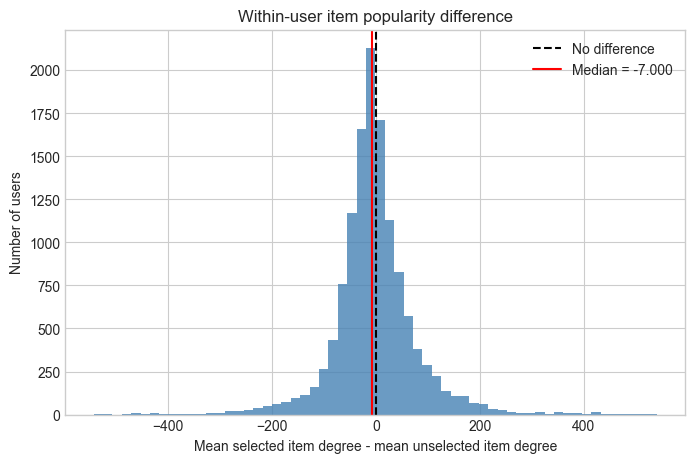

In [15]:
import matplotlib.pyplot as plt

delta = item_degree_by_user["item_degree_delta"]

plt.figure(figsize=(8, 5))
plt.hist(delta, bins=60, color="steelblue", alpha=0.8)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="No difference"
)

plt.axvline(
    delta.median(),
    color="red",
    label=f"Median = {delta.median():.3f}"
)

plt.xlabel(
    "Mean selected item degree - mean unselected item degree"
)
plt.ylabel("Number of users")
plt.title("Within-user item popularity difference")
plt.legend()
plt.show()

### User degree versus item-degree selection direction

Split eligible users by whether their selected items have lower or higher mean item degree than their unselected items, then compare user activity (`user_degree`).

In [16]:
from scipy.stats import spearmanr

item_degree_by_user["user_degree"] = user_degree[
    item_degree_by_user.index.to_numpy(dtype=np.int64)
]
item_degree_by_user["selection_direction"] = np.select(
    [
        item_degree_by_user.item_degree_delta < 0,
        item_degree_by_user.item_degree_delta > 0,
    ],
    ["lower_item_degree", "higher_item_degree"],
    default="equal_item_degree",
)

user_degree_summary = (
    item_degree_by_user.groupby("selection_direction")["user_degree"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        q90=lambda values: values.quantile(0.90),
    )
    .reindex(["lower_item_degree", "equal_item_degree", "higher_item_degree"])
)

lower_group = item_degree_by_user.loc[
    item_degree_by_user.selection_direction.eq("lower_item_degree"),
    "user_degree",
].to_numpy()
higher_group = item_degree_by_user.loc[
    item_degree_by_user.selection_direction.eq("higher_item_degree"),
    "user_degree",
].to_numpy()

user_degree_u, user_degree_p = mannwhitneyu(
    lower_group, higher_group, alternative="two-sided"
)
user_degree_rank_biserial = (
    2.0 * user_degree_u / (len(lower_group) * len(higher_group)) - 1.0
)
spearman_rho, spearman_p = spearmanr(
    item_degree_by_user.user_degree,
    item_degree_by_user.item_degree_delta,
)

print(f"Mann-Whitney p-value: {user_degree_p:.3e}")
print(f"Rank-biserial effect size: {user_degree_rank_biserial:.6f}")
print(f"Spearman rho(user degree, item-degree delta): {spearman_rho:.6f}")
print(f"Spearman p-value: {spearman_p:.3e}")
user_degree_summary

Mann-Whitney p-value: 1.515e-04
Rank-biserial effect size: 0.038294
Spearman rho(user degree, item-degree delta): 0.000609
Spearman p-value: 9.449e-01


,users,mean,median,q25,q75,q90
selection_direction,,,,,,
lower_item_degree,7253,7.003998,5.000000,3.000000,8.000000,13.000000
equal_item_degree,19,4.578947,4.000000,3.000000,5.000000,7.200000
higher_item_degree,5650,6.234867,5.000000,3.000000,7.000000,11.000000


C:\Users\vulam\AppData\Local\Temp\ipykernel_3156\1978714151.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


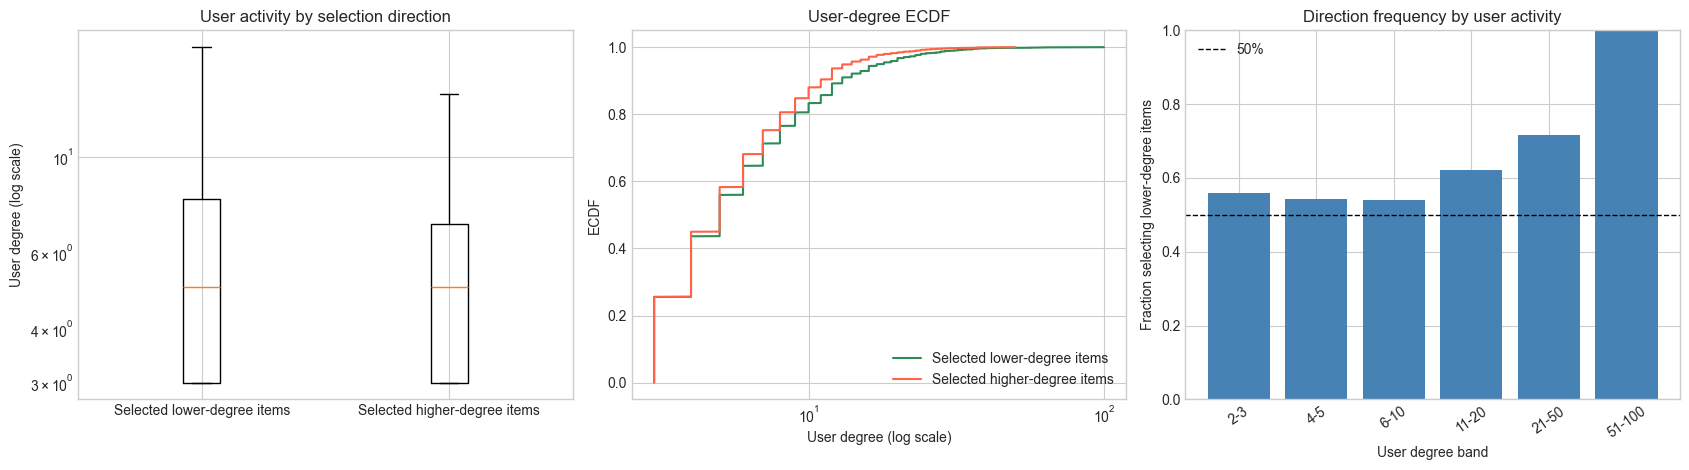

,users,lower_fraction
user_degree_band,,
2-3,3302,0.560267
4-5,4064,0.543307
6-10,3668,0.541167
11-20,1563,0.622521
21-50,310,0.716129
51-100,15,1.000000


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].boxplot(
    [lower_group, higher_group],
    labels=["Selected lower-degree items", "Selected higher-degree items"],
    showfliers=False,
    whis=(5, 95),
)
axes[0].set_yscale("log")
axes[0].set(ylabel="User degree (log scale)", title="User activity by selection direction")

for values, label, color in [
    (lower_group, "Selected lower-degree items", "seagreen"),
    (higher_group, "Selected higher-degree items", "tomato"),
]:
    x_values, y_values = ecdf(values)
    axes[1].plot(x_values, y_values, label=label, color=color)
axes[1].set_xscale("log")
axes[1].set(xlabel="User degree (log scale)", ylabel="ECDF", title="User-degree ECDF")
axes[1].legend()

degree_bins = [1, 3, 5, 10, 20, 50, 100, np.inf]
degree_labels = ["2-3", "4-5", "6-10", "11-20", "21-50", "51-100", "100+"]
item_degree_by_user["user_degree_band"] = pd.cut(
    item_degree_by_user.user_degree,
    bins=degree_bins,
    labels=degree_labels,
    include_lowest=True,
)
lower_fraction_by_degree = (
    item_degree_by_user.assign(
        selected_lower=item_degree_by_user.item_degree_delta < 0
    )
    .groupby("user_degree_band", observed=True)
    .agg(users=("selected_lower", "size"), lower_fraction=("selected_lower", "mean"))
)
axes[2].bar(
    lower_fraction_by_degree.index.astype(str),
    lower_fraction_by_degree.lower_fraction,
    color="steelblue",
)
axes[2].axhline(0.5, color="black", linestyle="--", linewidth=1, label="50%")
axes[2].set(
    xlabel="User degree band",
    ylabel="Fraction selecting lower-degree items",
    title="Direction frequency by user activity",
)
axes[2].tick_params(axis="x", rotation=35)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()
lower_fraction_by_degree

| Chỉ số | Giá trị |
|---|---:|
| User có delta âm | 56.13% |
| User có delta dương | 43.72% |
| Median delta | -7.0 |
| Mean delta | -2.76 |
| Standard deviation | 82.53 |
| Cohen’s \(d_z\) | -0.0335 |

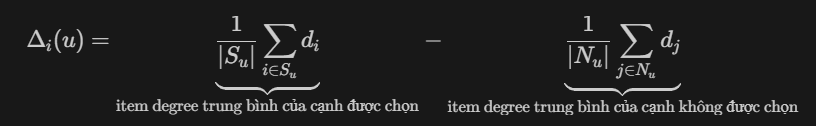

## 3. Within-user visual/text affinity

Use the masked branch's `second_user_*` tables. Item features are transformed with the learned `image_trs` and `text_trs` layers before cosine similarity is calculated.

In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state = checkpoint['model_state_dict']
required_keys = {
    'second_user_image.weight', 'second_user_text.weight',
    'image_embedding.weight', 'text_embedding.weight',
    'image_trs.weight', 'image_trs.bias',
    'text_trs.weight', 'text_trs.bias',
}
missing_keys = required_keys.difference(state)
assert not missing_keys, f'Missing checkpoint keys: {sorted(missing_keys)}'

with torch.no_grad():
    user_visual = F.normalize(state['second_user_image.weight'].float(), dim=1)
    user_textual = F.normalize(state['second_user_text.weight'].float(), dim=1)
    item_visual = F.normalize(
        F.linear(
            state['image_embedding.weight'].float(),
            state['image_trs.weight'].float(),
            state['image_trs.bias'].float(),
        ),
        dim=1,
    )
    item_textual = F.normalize(
        F.linear(
            state['text_embedding.weight'].float(),
            state['text_trs.weight'].float(),
            state['text_trs.bias'].float(),
        ),
        dim=1,
    )

assert user_visual.shape == user_textual.shape == (n_users, 64)
assert item_visual.shape == item_textual.shape == (n_items, 64)

edge_users = torch.from_numpy(edge_df.user_id.to_numpy(dtype=np.int64))
edge_items = torch.from_numpy(edge_df.item_id.to_numpy(dtype=np.int64))
with torch.no_grad():
    visual_similarity = (user_visual[edge_users] * item_visual[edge_items]).sum(dim=1)
    textual_similarity = (user_textual[edge_users] * item_textual[edge_items]).sum(dim=1)

edge_df['visual_similarity'] = visual_similarity.numpy()
edge_df['textual_similarity'] = textual_similarity.numpy()
assert np.isfinite(edge_df[['visual_similarity', 'textual_similarity']]).all().all()

del checkpoint, state, edge_users, edge_items, visual_similarity, textual_similarity
del user_visual, user_textual, item_visual, item_textual
gc.collect()

edge_modality_summary = (
    edge_df.groupby('selected')[['visual_similarity', 'textual_similarity']]
    .agg(['count', 'mean', 'median', 'std'])
    .rename(index={False: 'unselected', True: 'selected'})
)
edge_modality_summary

visual_similarity                            textual_similarity  \
                       count     mean   median      std              count   
selected                                                                     
unselected             82986 0.464973 0.478302 0.169402              82986   
selected               35565 0.570282 0.592044 0.163609              35565   

                                       
               mean   median      std  
selected                               
unselected 0.485102 0.496551 0.152706  
selected   0.607562 0.620418 0.133698

In [9]:
score_columns = ['visual_similarity', 'textual_similarity']
selected_user_scores = (
    edge_df.loc[edge_df.selected]
    .groupby('user_id')[score_columns]
    .mean()
    .rename(columns={
        'visual_similarity': 'visual_selected',
        'textual_similarity': 'textual_selected',
    })
)
unselected_user_scores = (
    edge_df.loc[~edge_df.selected]
    .groupby('user_id')[score_columns]
    .mean()
    .rename(columns={
        'visual_similarity': 'visual_unselected',
        'textual_similarity': 'textual_unselected',
    })
)
user_modality = selected_user_scores.join(unselected_user_scores, how='inner')
user_modality['delta_visual'] = user_modality.visual_selected - user_modality.visual_unselected
user_modality['delta_textual'] = user_modality.textual_selected - user_modality.textual_unselected
user_modality['delta_modality'] = user_modality.delta_visual - user_modality.delta_textual

def bootstrap_median_ci(values, n_bootstrap=1000, seed=999):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    bootstrapped = np.empty(n_bootstrap, dtype=np.float64)
    for index in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrapped[index] = np.median(sample)
    return np.quantile(bootstrapped, [0.025, 0.975])

summary_rows = []
for label, column in [
    ('visual', 'delta_visual'),
    ('textual', 'delta_textual'),
    ('visual_minus_textual', 'delta_modality'),
]:
    values = user_modality[column].to_numpy()
    ci_low, ci_high = bootstrap_median_ci(values)
    test = wilcoxon(values, alternative='two-sided')
    summary_rows.append({
        'comparison': label,
        'users': len(values),
        'mean_delta': values.mean(),
        'median_delta': np.median(values),
        'median_ci_low': ci_low,
        'median_ci_high': ci_high,
        'wilcoxon_p_value': test.pvalue,
    })

modality_summary = pd.DataFrame(summary_rows).set_index('comparison')
print(f'Users with both edge groups: {len(user_modality):,}/{users_in_graph:,}')
print(f'Excluded users: {users_in_graph - len(user_modality):,}')
modality_summary

Users with both edge groups: 12,922/19,445
Excluded users: 6,523


,users,mean_delta,median_delta,median_ci_low,median_ci_high,wilcoxon_p_value
comparison,,,,,,
visual,12922,0.046414,0.050693,0.048033,0.053190,0.000000
textual,12922,0.056831,0.059925,0.056843,0.062893,0.000000
visual_minus_textual,12922,-0.010417,-0.010541,-0.014169,-0.007428,0.000000


C:\Users\vulam\AppData\Local\Temp\ipykernel_3156\3243010724.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


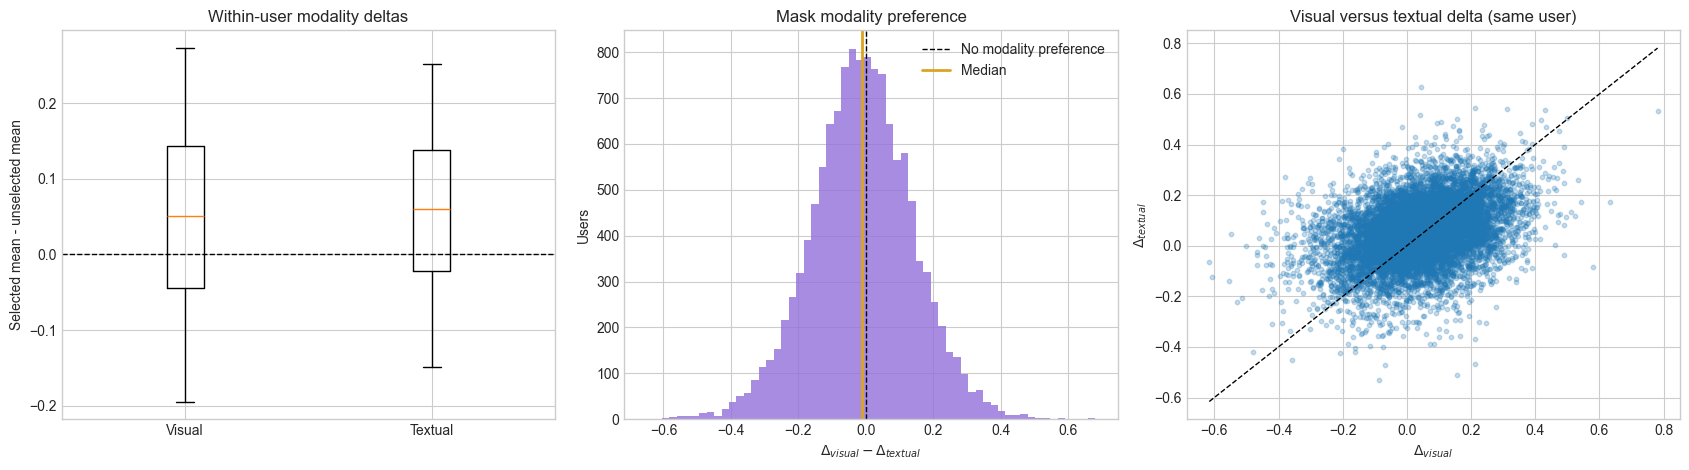

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].boxplot(
    [user_modality.delta_visual, user_modality.delta_textual],
    labels=['Visual', 'Textual'],
    showfliers=False,
    whis=(5, 95),
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set(ylabel='Selected mean - unselected mean', title='Within-user modality deltas')

axes[1].hist(user_modality.delta_modality, bins=60, color='mediumpurple', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label='No modality preference')
axes[1].axvline(
    user_modality.delta_modality.median(),
    color='goldenrod', linestyle='-', linewidth=2, label='Median'
)
axes[1].set(xlabel=r'$\Delta_{visual} - \Delta_{textual}$', ylabel='Users', title='Mask modality preference')
axes[1].legend()

plot_data = user_modality
if len(plot_data) > 10000:
    plot_data = plot_data.sample(10000, random_state=999)
axes[2].scatter(plot_data.delta_visual, plot_data.delta_textual, s=10, alpha=0.25)
lower = min(plot_data.delta_visual.min(), plot_data.delta_textual.min())
upper = max(plot_data.delta_visual.max(), plot_data.delta_textual.max())
axes[2].plot([lower, upper], [lower, upper], color='black', linestyle='--', linewidth=1)
axes[2].set(
    xlabel=r'$\Delta_{visual}$', ylabel=r'$\Delta_{textual}$',
    title='Visual versus textual delta (same user)'
)

plt.tight_layout()
plt.show()

| Modality | Median delta | Tỷ lệ delta > 0 |
|---|---:|---:|
| Visual | 0.0507 | 63.9% |
| Textual | 0.0599 | 69.1% |

| Vùng | Ý nghĩa | Tỷ lệ user |
|---|---|---:|
| X > 0, Y > 0 | Selected tốt hơn ở cả hai modality | 49.83% |
| X ≤ 0, Y > 0 | Chỉ textual tốt hơn | 19.23% |
| X > 0, Y ≤ 0 | Chỉ visual tốt hơn | 14.08% |
| X ≤ 0, Y ≤ 0 | Không tốt hơn ở cả hai | 16.86% |

In [11]:
median_visual = user_modality.delta_visual.median()
median_textual = user_modality.delta_textual.median()
median_preference = user_modality.delta_modality.median()
preference_label = 'visual' if median_preference > 0 else 'textual' if median_preference < 0 else 'neither'

print(f'Median visual delta: {median_visual:.6f}')
print(f'Median textual delta: {median_textual:.6f}')
print(f'Median visual-textual preference: {median_preference:.6f}')
print(f'Descriptive direction: {preference_label}')
print('Reminder: these results describe association with mask selection, not a causal effect on recommendation quality.')

Median visual delta: 0.050693
Median textual delta: 0.059925
Median visual-textual preference: -0.010541
Descriptive direction: textual
Reminder: these results describe association with mask selection, not a causal effect on recommendation quality.


| Nhóm user | Số lượng | Tỷ lệ |
|---|---:|---:|
| Chỉ có cạnh selected | 1.836 | **9,44%** |
| Chỉ có cạnh unselected | 4.687 | **24,10%** |
| Có cả selected và unselected | 12.922 | **66,45%** |
| Không có cạnh training | 0 | **0%** |

## 5. Degree-modality affinity overlap

This section asks whether high-affinity edges are also high-degree edges and whether the learned mask prefers particular degree-affinity combinations. The primary analysis uses within-user percentiles, so a high-degree edge means an item is relatively popular among that user's training items. Visual and textual affinity are analysed separately.

In [18]:
from scipy.stats import spearmanr

def within_user_percentile(frame, value_column):
    # (rank - 1) / (n - 1) maps the smallest/largest value to 0/1.
    # A user with one edge has no within-user ordering, so assign 0.5.
    grouped = frame.groupby('user_id')[value_column]
    ranks = grouped.rank(method='average')
    sizes = grouped.transform('size')
    percentile = (ranks - 1.0) / (sizes - 1.0)
    return percentile.where(sizes.gt(1), 0.5)

overlap_df = edge_df[[
    'edge_id', 'user_id', 'item_id', 'selected', 'mask_probability',
    'user_degree', 'item_degree', 'edge_degree',
    'visual_similarity', 'textual_similarity',
]].copy()
overlap_df['log_edge_degree'] = np.log1p(overlap_df.edge_degree)
overlap_df['log_item_degree'] = np.log1p(overlap_df.item_degree)
overlap_df['degree_percentile_user'] = within_user_percentile(overlap_df, 'item_degree')
overlap_df['visual_percentile_user'] = within_user_percentile(overlap_df, 'visual_similarity')
overlap_df['textual_percentile_user'] = within_user_percentile(overlap_df, 'textual_similarity')

required = [
    'log_edge_degree', 'log_item_degree', 'degree_percentile_user',
    'visual_percentile_user', 'textual_percentile_user',
]
assert np.isfinite(overlap_df[required].to_numpy()).all()
assert overlap_df[required].notna().all().all()

print(f'Edges available: {len(overlap_df):,}')
print(f'Users available: {overlap_df.user_id.nunique():,}')
print(f'Users with one training edge: {(overlap_df.user_degree.eq(1).groupby(overlap_df.user_id).first()).sum():,}')
overlap_df[[
    'user_id', 'item_id', 'item_degree', 'degree_percentile_user',
    'visual_similarity', 'visual_percentile_user',
    'textual_similarity', 'textual_percentile_user', 'selected',
]].head()

Edges available: 118,551
Users available: 19,445
Users with one training edge: 0


,user_id,item_id,item_degree,degree_percentile_user,visual_similarity,visual_percentile_user,textual_similarity,textual_percentile_user,selected
0,0,0,9,0.000000,0.728318,0.500000,0.691873,0.500000,True
1,0,1587,260,1.000000,0.390773,0.000000,0.463576,0.000000,False
2,0,1879,10,0.500000,0.801659,1.000000,0.738804,1.000000,True
3,1,0,9,0.333333,0.645281,0.333333,0.688122,1.000000,True
4,1,1434,25,1.000000,0.656491,0.666667,0.594148,0.000000,True


### 5.1 Continuous association and high-high overlap

`overlap_lift > 1` means high degree and high affinity co-occur more often than expected from their marginal rates. A value near 1 indicates little overlap beyond chance; a value below 1 indicates that high-affinity edges tend to avoid the high-degree group. Global thresholds are dataset-wide Q75 values. Within-user thresholds use the top 25% of each user's own edges.

In [19]:
association_rows = []
for modality, similarity_column, percentile_column in [
    ('visual', 'visual_similarity', 'visual_percentile_user'),
    ('textual', 'textual_similarity', 'textual_percentile_user'),
]:
    # Global relationship: absolute item popularity versus raw cosine affinity.
    global_rho, global_p = spearmanr(
        overlap_df.log_item_degree, overlap_df[similarity_column]
    )
    global_degree_high = overlap_df.item_degree.ge(overlap_df.item_degree.quantile(0.75))
    global_affinity_high = overlap_df[similarity_column].ge(
        overlap_df[similarity_column].quantile(0.75)
    )
    global_observed = (global_degree_high & global_affinity_high).mean()
    global_expected = global_degree_high.mean() * global_affinity_high.mean()

    # Within-user relationship: relative item popularity versus relative affinity.
    within_rho, within_p = spearmanr(
        overlap_df.degree_percentile_user, overlap_df[percentile_column]
    )
    within_degree_high = overlap_df.degree_percentile_user.ge(0.75)
    within_affinity_high = overlap_df[percentile_column].ge(0.75)
    within_observed = (within_degree_high & within_affinity_high).mean()
    within_expected = within_degree_high.mean() * within_affinity_high.mean()

    for scope, rho, p_value, observed, expected in [
        ('global', global_rho, global_p, global_observed, global_expected),
        ('within_user', within_rho, within_p, within_observed, within_expected),
    ]:
        association_rows.append({
            'scope': scope,
            'modality': modality,
            'spearman_rho': rho,
            'spearman_p_value': p_value,
            'observed_high_high_rate': observed,
            'expected_if_independent': expected,
            'overlap_lift': observed / expected if expected > 0 else np.nan,
        })

degree_affinity_association = pd.DataFrame(association_rows)
degree_affinity_association

,scope,modality,spearman_rho,spearman_p_value,observed_high_high_rate,expected_if_independent,overlap_lift
0,global,visual,-0.404705,0.000000,0.023062,0.062720,0.367692
1,within_user,visual,-0.410122,0.000000,0.039451,0.089549,0.440558
2,global,textual,-0.472912,0.000000,0.018490,0.062720,0.294799
3,within_user,textual,-0.489785,0.000000,0.030966,0.089549,0.345796


### 5.2 Four extreme degree-affinity groups

Low means percentile <= 0.25 and high means percentile >= 0.75 within the same user. Middle values are intentionally excluded to make the contrast clearer. `selection_lift` compares each group's selection rate with the overall hard-mask rate.

In [20]:
def extreme_label(values, low=0.25, high=0.75):
    return np.select(
        [values.le(low), values.ge(high)],
        ['Low', 'High'],
        default='Middle',
    )

base_selection_rate = overlap_df.selected.mean()
quadrant_frames = []
for modality, percentile_column in [
    ('visual', 'visual_percentile_user'),
    ('textual', 'textual_percentile_user'),
]:
    temporary = overlap_df[[
        'selected', 'mask_probability', 'degree_percentile_user', percentile_column
    ]].copy()
    temporary['degree_group'] = extreme_label(temporary.degree_percentile_user)
    temporary['affinity_group'] = extreme_label(temporary[percentile_column])
    temporary = temporary.loc[
        temporary.degree_group.ne('Middle') & temporary.affinity_group.ne('Middle')
    ]
    summary = (
        temporary.groupby(['degree_group', 'affinity_group'], observed=True)
        .agg(
            edges=('selected', 'size'),
            selected_edges=('selected', 'sum'),
            selection_rate=('selected', 'mean'),
            mean_mask_probability=('mask_probability', 'mean'),
        )
        .reset_index()
    )
    summary['modality'] = modality
    summary['edge_share_among_extremes'] = summary.edges / len(temporary)
    summary['selection_lift'] = summary.selection_rate / base_selection_rate
    quadrant_frames.append(summary)

degree_affinity_quadrants = pd.concat(quadrant_frames, ignore_index=True)
degree_affinity_quadrants = degree_affinity_quadrants[[
    'modality', 'degree_group', 'affinity_group', 'edges', 'selected_edges',
    'edge_share_among_extremes', 'selection_rate',
    'selection_lift', 'mean_mask_probability',
]]
print(f'Overall selection rate: {base_selection_rate:.2%}')
degree_affinity_quadrants.sort_values(
    ['modality', 'degree_group', 'affinity_group']
).reset_index(drop=True)

Overall selection rate: 30.00%


,modality,degree_group,affinity_group,edges,selected_edges,edge_share_among_extremes,selection_rate,selection_lift,mean_mask_probability
0,textual,High,High,3671,1681,0.077621,0.457913,1.526391,0.284756
1,textual,High,Low,20314,4868,0.429526,0.239638,0.798799,0.272383
2,textual,Low,High,19191,7141,0.405781,0.372102,1.240349,0.281299
3,textual,Low,Low,4118,1183,0.087072,0.287275,0.957593,0.275482
4,visual,High,High,4677,1743,0.101247,0.372675,1.242260,0.279578
5,visual,High,Low,18321,4937,0.396610,0.269472,0.898248,0.274572
6,visual,Low,High,18025,6867,0.390202,0.380971,1.269914,0.281462
7,visual,Low,Low,5171,1346,0.111941,0.260298,0.867667,0.274958


### 5.3 Selection-rate heatmaps

The lower-left corner contains low-degree, low-affinity edges; the upper-right contains high-degree, high-affinity edges. Colour is the fraction of edges selected by the final hard mask. The dashed contour marks the overall selection rate.

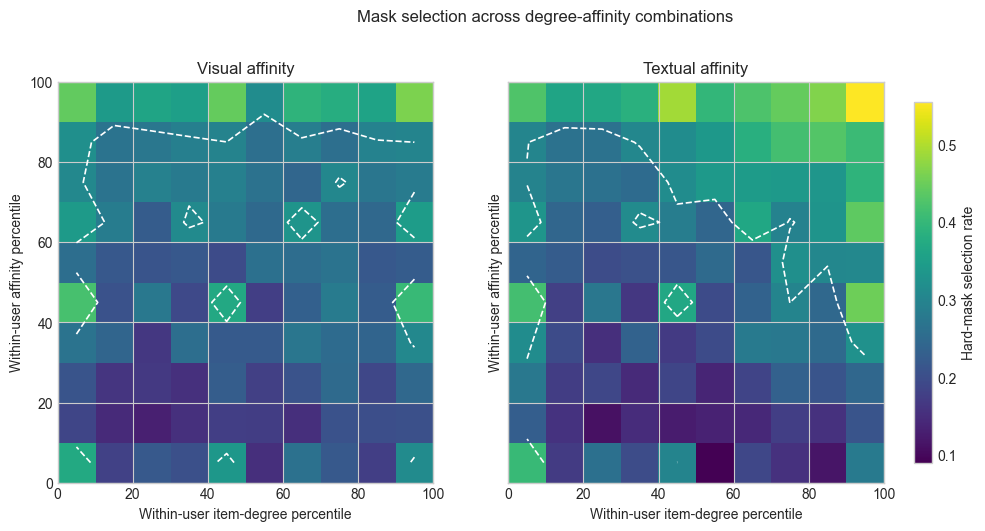

In [21]:
heatmap_tables = {}
bin_edges = np.linspace(0.0, 1.0, 11)
degree_bin = pd.cut(
    overlap_df.degree_percentile_user, bins=bin_edges, labels=False,
    include_lowest=True, duplicates='drop',
)

for modality, percentile_column in [
    ('Visual', 'visual_percentile_user'),
    ('Textual', 'textual_percentile_user'),
]:
    affinity_bin = pd.cut(
        overlap_df[percentile_column], bins=bin_edges, labels=False,
        include_lowest=True, duplicates='drop',
    )
    binned = pd.DataFrame({
        'degree_bin': degree_bin,
        'affinity_bin': affinity_bin,
        'selected': overlap_df.selected.to_numpy(),
    })
    heatmap_tables[modality] = (
        binned.groupby(['affinity_bin', 'degree_bin'], observed=True).selected.mean()
        .unstack()
        .reindex(index=range(10), columns=range(10))
    )

all_rates = np.concatenate([table.to_numpy().ravel() for table in heatmap_tables.values()])
finite_rates = all_rates[np.isfinite(all_rates)]
common_min, common_max = finite_rates.min(), finite_rates.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
images = []
for axis, (modality, table) in zip(axes, heatmap_tables.items()):
    image = axis.imshow(
        table.to_numpy(), origin='lower', aspect='auto',
        extent=[0, 100, 0, 100], cmap='viridis',
        vmin=common_min, vmax=common_max,
    )
    images.append(image)
    # Draw the cells whose rate equals the global 30% baseline approximately.
    x_centres = np.arange(5, 100, 10)
    y_centres = np.arange(5, 100, 10)
    if common_min < base_selection_rate < common_max:
        axis.contour(
            x_centres, y_centres, table.to_numpy(),
            levels=[base_selection_rate], colors='white', linestyles='--', linewidths=1.2,
        )
    axis.set(
        title=f'{modality} affinity',
        xlabel='Within-user item-degree percentile',
        ylabel='Within-user affinity percentile',
    )

colorbar = fig.colorbar(images[0], ax=axes, shrink=0.9, pad=0.03)
colorbar.set_label('Hard-mask selection rate')
fig.suptitle('Mask selection across degree-affinity combinations', y=1.02)
plt.show()

### 5.4 Joint logistic model with degree-affinity interactions

The model uses within-user percentiles centred at 0.5. Positive `degree_x_visual` or `degree_x_textual` means the affinity-selection relationship becomes stronger for relatively popular items; a negative interaction means it becomes stronger for relatively less-popular items. Visual and textual terms are fitted jointly. Standard errors are clustered by user.

In [22]:
try:
    import statsmodels.api as sm
except ImportError:
    print('Optional logistic model skipped: statsmodels is not installed in this kernel.')
    degree_affinity_logistic = None
else:
    degree_c = overlap_df.degree_percentile_user - 0.5
    visual_c = overlap_df.visual_percentile_user - 0.5
    textual_c = overlap_df.textual_percentile_user - 0.5
    design = pd.DataFrame({
        'degree': degree_c,
        'visual_affinity': visual_c,
        'textual_affinity': textual_c,
        'degree_x_visual': degree_c * visual_c,
        'degree_x_textual': degree_c * textual_c,
    })
    design = sm.add_constant(design, has_constant='add')
    logistic_fit = sm.GLM(
        overlap_df.selected.astype(np.int8),
        design,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': overlap_df.user_id.to_numpy()},
    )
    confidence_interval = logistic_fit.conf_int()
    degree_affinity_logistic = pd.DataFrame({
        'coefficient': logistic_fit.params,
        'clustered_se': logistic_fit.bse,
        'odds_ratio': np.exp(logistic_fit.params),
        'ci_low': confidence_interval[0],
        'ci_high': confidence_interval[1],
        'p_value': logistic_fit.pvalues,
    })
    degree_affinity_logistic['odds_ratio_ci_low'] = np.exp(degree_affinity_logistic.ci_low)
    degree_affinity_logistic['odds_ratio_ci_high'] = np.exp(degree_affinity_logistic.ci_high)
    display(degree_affinity_logistic)
    print('Interaction interpretation:')
    for term in ['degree_x_visual', 'degree_x_textual']:
        coefficient = degree_affinity_logistic.loc[term, 'coefficient']
        direction = 'high-degree items' if coefficient > 0 else 'low-degree items'
        print(f'- {term}: affinity-selection association is stronger toward {direction}.')

Optional logistic model skipped: statsmodels is not installed in this kernel.


### Reading the results

Use the heatmaps and selection lift for effect direction and magnitude; do not interpret a tiny p-value alone as a practically important effect. Raw affinity, user embeddings, and mask weights were learned jointly, so this section describes association rather than a causal reason for mask selection or recommendation performance.